In [5]:
import matplotlib.pyplot as plt
import cv2
import os
from pathlib import Path

from wrapper import add_noise

# Загружаем изображение (предполагается, что файл лежит рядом с ipynb)
image = cv2.imread("/Users/v.makshanchikov/Documents/Python Proj/ВКР Магистратура/mall_dataset/frames/seq_000001.jpg")
# image = cv2.imread("/Users/v.makshanchikov/Documents/Python Proj/ВКР Магистратура/noises/image.jpg")
# Создаём папку для результатов
output_dir = "noisy_images"
Path(output_dir).mkdir(exist_ok=True)

# Создаём словарь с параметрами для каждого типа шума
noise_configs = {
    "gaussian": {
        "params": {"mean": 0, "var": 0.1},
        "title": "Gaussian Noise"
    },
    "salt_pepper": {
        "params": {"salt_prob": 0.05, "pepper_prob": 0.05},
        "title": "Salt & Pepper Noise"
    },
    "speckle": {
        "params": {"speckle_scale": 0.5},
        "title": "Speckle Noise"
    },
    "poisson": {
        "params": {"poisson_scale": 0.2},
        "title": "Poisson Noise"
    }
}

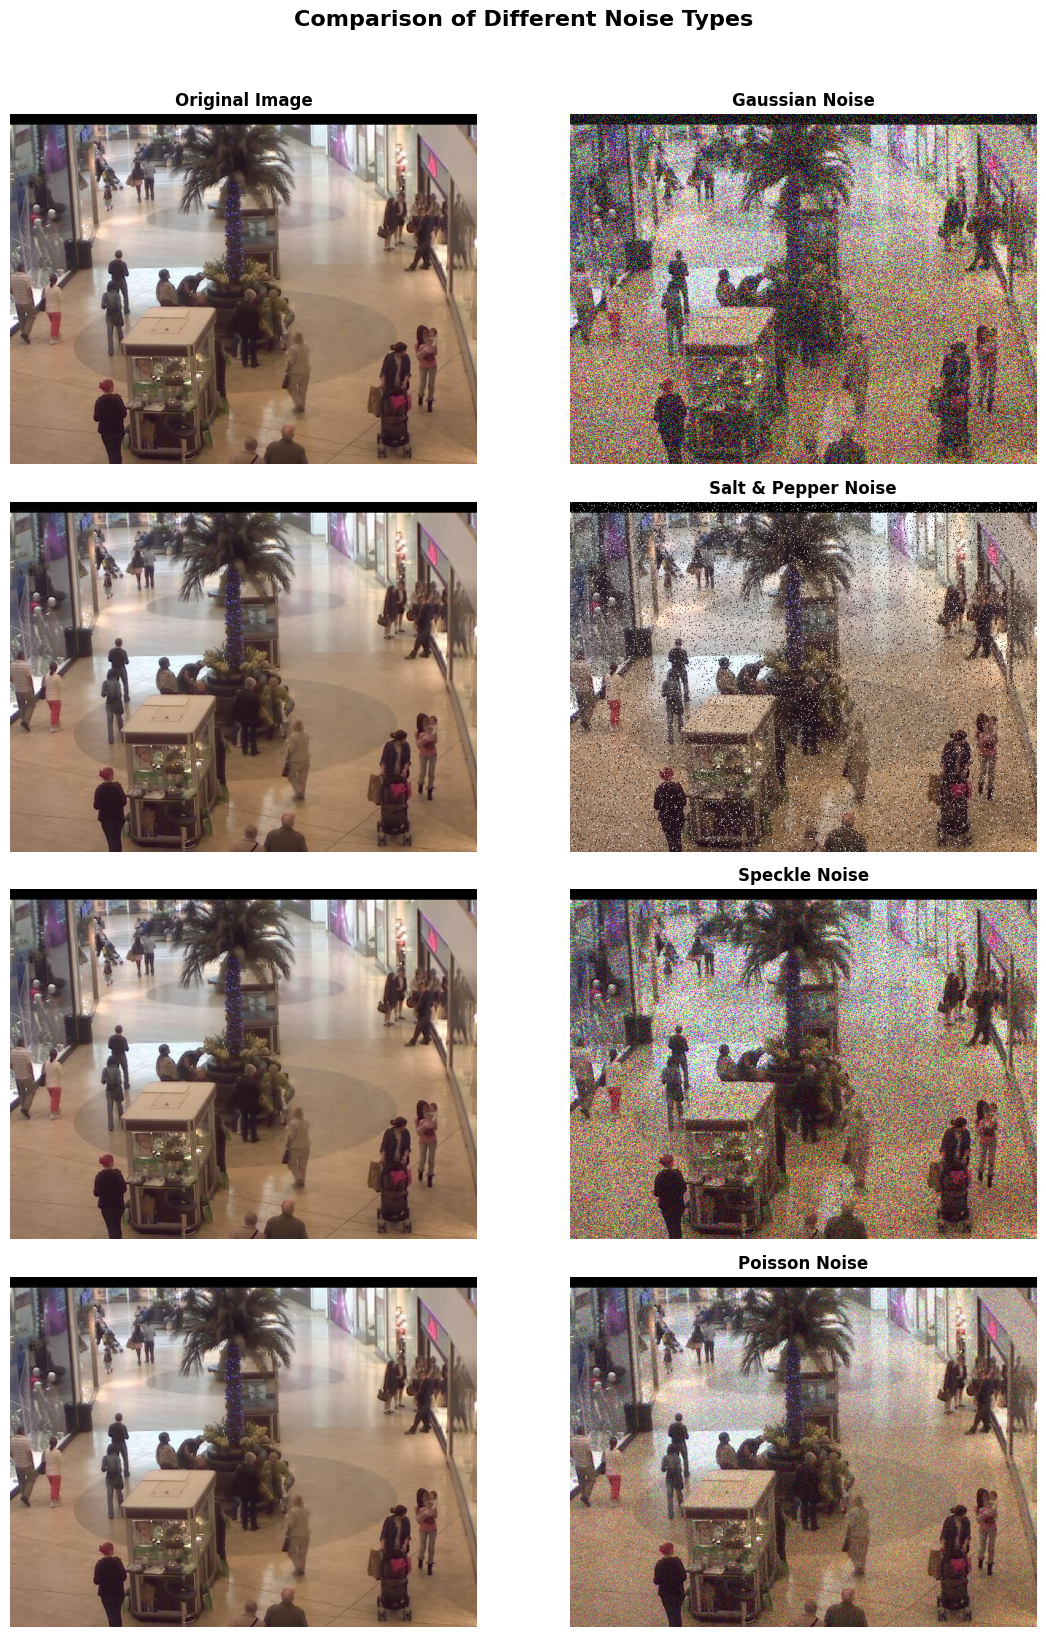

In [6]:
# Создаём фигуру с подзаголовками для всех типов шумов
fig, axes = plt.subplots(len(noise_configs), 2, figsize=(12, 4 * len(noise_configs)))

for idx, (noise_type, config) in enumerate(noise_configs.items()):
    noisy_image = add_noise(image, noise_type=noise_type, **config["params"])
    
    output_filename = os.path.join(output_dir, f"{noise_type}_image.jpg")
    cv2.imwrite(output_filename, noisy_image)
    
    if idx == 0:
        axes[idx, 0].set_title("Original Image", fontsize=12, fontweight='bold')
        axes[idx, 0].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
        axes[idx, 0].axis("off")
    else:
        axes[idx, 0].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
        axes[idx, 0].axis("off")
    
    # Зашумлённое изображение
    axes[idx, 1].set_title(config["title"], fontsize=12, fontweight='bold')
    axes[idx, 1].imshow(cv2.cvtColor(noisy_image, cv2.COLOR_BGR2RGB))
    axes[idx, 1].axis("off")

# Общий заголовок
fig.suptitle("Comparison of Different Noise Types", fontsize=16, fontweight='bold', y=1.02)

# Отступы между подзаголовками
plt.tight_layout()
plt.show()